# PatchCore + DINOv2 Layer-Wise Ablation | Checkpoint 3
## Comparative Analysis of Vision Foundation Models for Few-Shot Industrial Anomaly Detection
**Author:** Phumapiwat Chanyuthagorn | RIT MS in Artificial Intelligence | Spring 2026

### Checkpoint 3 Deliverables:
1. **Core Algorithm:** PatchCore + DINOv2 ViT-B/14 with block-level ablation (blocks 3, 6, 9, 12)
2. **Baseline:** PatchCore + ResNet-50 (from Checkpoint 2)
3. **Fair Comparison:** Adaptive coreset ratio to ensure few-shot memory banks are representative
4. **Multi-Category Evaluation:** Bottle (primary) + Cable, Hazelnut, Leather, Tile
5. **Full Results:** 5 models x 4 shot counts x 5 categories = 100 experiments

### Key Methodological Fix Since Checkpoint 2:
Checkpoint 2 used a fixed 1% coreset ratio. With 1 training image (784 ResNet patches or 256 DINOv2 patches), 1% leaves only 2-7 patches in the memory bank -- too sparse for meaningful nearest-neighbor scoring. This checkpoint implements **adaptive coreset sizing** that scales with training set size, ensuring fair comparison across all shot counts.

### Overview:
- Cells 1-4: Setup & data
- Cells 5-6: Model definitions (ResNet-50 + DINOv2 extractor + unified PatchCore)
- Cell 7: Memory bank construction with checkpoints & logs (**Training Snapshot**)
- Cell 8: Live inference visualization (**Testing/Inference**)
- Cells 9-11: Comparison table, ablation heatmap, summary (**Comparison Results**)

In [1]:
# -- CELL 1 : Install dependencies -----------------------------------------------
# Run once. Runtime may restart -- that is normal. After restart, skip to Cell 2.

!pip install anomalib==1.1.0 timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.5/786.5 kB 25.7 MB/s eta 0:00:00


In [2]:
# -- CELL 2 : Setup dataset -------------------------------------------------------
# Upload category zip files to /content/ before running.
# Required: bottle.zip (primary testbed)
# Optional: cable.zip, hazelnut.zip, leather.zip, tile.zip (for multi-category eval)

!mkdir -p /content/datasets/

In [3]:
# Unzip all available categories
import os
for zipname in ["bottle", "cable", "hazelnut", "leather", "tile"]:
    zippath = f"/content/{zipname}.zip"
    if os.path.exists(zippath):
        os.system(f"unzip -qo {zippath} -d /content/datasets/")
        print(f"  Unzipped: {zipname}")
    elif os.path.exists(f"/content/{zipname}"):
        os.system(f"unzip -qo /content/{zipname} -d /content/datasets/")
        print(f"  Unzipped: {zipname}")
    else:
        print(f"  Skipped: {zipname} (not uploaded)")

# Verify structure
print("\nDataset structure:")
for cat in sorted(os.listdir("/content/datasets/")):
    cat_path = f"/content/datasets/{cat}"
    if os.path.isdir(cat_path):
        for split in ['train', 'test']:
            split_path = os.path.join(cat_path, split)
            if os.path.exists(split_path):
                n_sub = sum(len(os.listdir(os.path.join(split_path, s)))
                           for s in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, s)))
                print(f"  {cat}/{split}: {n_sub} images")

  Unzipped: bottle
  Unzipped: cable
  Unzipped: hazelnut
  Unzipped: leather
  Unzipped: tile

Dataset structure:
  bottle/train: 209 images
  bottle/test: 83 images
  cable/train: 224 images
  cable/test: 150 images
  hazelnut/train: 391 images
  hazelnut/test: 110 images
  leather/train: 245 images
  leather/test: 124 images
  tile/train: 230 images
  tile/test: 117 images


In [4]:
# -- CELL 3 : Imports and configuration -------------------------------------------
import random, time, warnings, os, json, datetime, gc
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import roc_auc_score
from PIL import Image

# -- Paths --
DATASET_ROOT = Path("/content/datasets")
CKPT_DIR     = Path("/content/checkpoints")
LOG_DIR      = Path("/content/logs")
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

# -- Experiment settings --
CATEGORIES      = []  # auto-detect available categories
for d in sorted(DATASET_ROOT.iterdir()):
    if d.is_dir() and (d / "train" / "good").exists():
        CATEGORIES.append(d.name)
print(f"Available categories: {CATEGORIES}")

SHOT_COUNTS     = [1, 5, 10, -1]        # -1 = full
ABLATION_BLOCKS = [3, 6, 9, 12]         # DINOv2 block depths
IMAGE_SIZE      = 224
BATCH_SIZE      = 32
SEED            = 42
GRID_SIZE       = 16                     # 224 / 14 = 16

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

# -- Adaptive coreset ratio --
# Fixed 1% fails at low shot counts: 1 image -> 256 DINOv2 patches -> 1% = 2 patches.
# This adaptive function ensures a minimum meaningful memory bank size.
def get_subsample_ratio(n_shot):
    if n_shot is None:       # Full dataset (100+ images)
        return 0.01          # 1% — standard PatchCore setting
    elif n_shot <= 1:
        return 1.0           # Keep ALL patches — only 256 per image
    elif n_shot <= 5:
        return 0.25          # 25% — keeps ~320 patches for 5 images
    elif n_shot <= 10:
        return 0.1           # 10% — keeps ~256 patches for 10 images
    else:
        return 0.05          # 5% for moderate training sets

# Verify ratios
print("\nAdaptive coreset ratios:")
for n in [1, 5, 10, None]:
    r = get_subsample_ratio(n)
    label = "Full" if n is None else f"{n}-shot"
    if n is not None:
        dino_patches = n * 256
        kept = max(1, int(dino_patches * r))
        print(f"  {label:>8s}: ratio={r:.0%} | DINOv2: {dino_patches} -> {kept} patches")
    else:
        print(f"  {label:>8s}: ratio={r:.0%} | DINOv2: ~53504 -> ~535 patches")

Available categories: ['bottle', 'cable', 'hazelnut', 'leather', 'tile']
PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4

Adaptive coreset ratios:
    1-shot: ratio=100% | DINOv2: 256 -> 256 patches
    5-shot: ratio=25% | DINOv2: 1280 -> 320 patches
   10-shot: ratio=10% | DINOv2: 2560 -> 256 patches
      Full: ratio=1% | DINOv2: ~53504 -> ~535 patches


In [5]:
# -- CELL 4 : Dataset class --------------------------------------------------------

class MVTecFewShotDataset(Dataset):
    """MVTec AD loader with few-shot support."""

    def __init__(self, root, split="train", n_shot=None, image_size=224, seed=42):
        self.root = Path(root)
        self.split = split
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        self.samples = []
        self._load_samples(n_shot, seed)

    def _load_samples(self, n_shot, seed):
        if self.split == "train":
            normal_dir = self.root / "train" / "good"
            paths = sorted(normal_dir.glob("*.png")) + sorted(normal_dir.glob("*.jpg"))
            if n_shot is not None:
                rng = random.Random(seed)
                paths = rng.sample(paths, min(n_shot, len(paths)))
            self.samples = [(p, 0, None) for p in paths]
        elif self.split == "test":
            test_dir = self.root / "test"
            mask_dir = self.root / "ground_truth"
            for defect_type in sorted(test_dir.iterdir()):
                if not defect_type.is_dir():
                    continue
                label = 0 if defect_type.name == "good" else 1
                img_paths = sorted(defect_type.glob("*.png")) + sorted(defect_type.glob("*.jpg"))
                for img_path in img_paths:
                    if label == 0:
                        self.samples.append((img_path, label, None))
                    else:
                        mask_path = mask_dir / defect_type.name / (img_path.stem + "_mask.png")
                        self.samples.append((img_path, label,
                                             mask_path if mask_path.exists() else None))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, mask_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        mask = torch.zeros(1, self.image_size, self.image_size)
        if mask_path is not None and mask_path.exists():
            m = Image.open(mask_path).convert("L")
            m = transforms.Resize((self.image_size, self.image_size),
                                  interpolation=transforms.InterpolationMode.NEAREST)(m)
            mask = (transforms.ToTensor()(m) > 0.5).float()
        return {"image": image, "label": label, "mask": mask, "path": str(img_path)}


def make_loaders(category, n_shot, dataset_root=DATASET_ROOT,
                 image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, seed=SEED):
    root = dataset_root / category
    train_ds = MVTecFewShotDataset(root, "train", n_shot=n_shot,
                                    image_size=image_size, seed=seed)
    test_ds  = MVTecFewShotDataset(root, "test", n_shot=None,
                                    image_size=image_size, seed=seed)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)
    label = "Full" if n_shot is None else f"{n_shot}-shot"
    print(f"  [{category}] {label} | train={len(train_ds)} | test={len(test_ds)}")
    return train_loader, test_loader

# Quick check on first available category
print("Dataset check:")
_ = make_loaders(CATEGORIES[0], n_shot=5)

Dataset check:
  [bottle] 5-shot | train=5 | test=83


In [6]:
# -- CELL 5 : Feature Extractors ---------------------------------------------------

def neighbourhood_pool(features, kernel_size=3):
    """Average pool to aggregate local neighbourhood context."""
    return F.avg_pool2d(features, kernel_size=kernel_size,
                        stride=1, padding=kernel_size // 2)


def coreset_subsample(features, ratio=0.01, seed=42):
    """Random coreset subsampling."""
    N = features.shape[0]
    n_keep = max(1, int(N * ratio))
    if n_keep >= N:
        return features
    rng = np.random.default_rng(seed)
    idx = rng.choice(N, size=n_keep, replace=False)
    print(f"    Coreset: {N} -> {n_keep} patches ({ratio*100:.1f}%)")
    return features[idx]


# ==========================================================================
# BASELINE: ResNet-50 extractor (from Checkpoint 2)
# ==========================================================================
class ResNet50Extractor(nn.Module):
    """ResNet-50 layer2+layer3 -> 1536-dim patch descriptors."""
    def __init__(self, device):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        backbone.eval()
        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1,
                                     backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.to(device)
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        x  = self.layer0(x)
        x  = self.layer1(x)
        f2 = self.layer2(x)    # [B, 512, H/8, W/8]
        f3 = self.layer3(f2)   # [B, 1024, H/16, W/16]
        return f2, f3


# ==========================================================================
# PROPOSED METHOD: DINOv2 ViT-B/14 extractor with block-level ablation
# ==========================================================================
class DINOv2Extractor(nn.Module):
    """
    DINOv2 ViT-B/14 feature extractor with block-level ablation support.

    Architecture: 12 Transformer blocks, 768-dim, patch_size=14.
    Uses forward hooks to capture intermediate block outputs without
    modifying the model or running separate forward passes.

    For 224x224 input: 224/14 = 16 patches per side -> 256 patch tokens + 1 CLS.
    CLS token is dropped; patch tokens reshaped to [B, 768, 16, 16] spatial grid.
    """
    def __init__(self, block_indices, device="cuda"):
        super().__init__()
        self.block_indices = block_indices
        self.device = device
        self.grid_size = GRID_SIZE

        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
        self.backbone.eval()
        self.backbone.to(device)

        for p in self.backbone.parameters():
            p.requires_grad = False

        self._features = {}
        for idx in block_indices:
            block = self.backbone.blocks[idx - 1]
            block.register_forward_hook(self._make_hook(idx))

        self.feat_dim = 768 * len(block_indices)
        print(f"  DINOv2 extractor | blocks={block_indices} | "
              f"feat_dim={self.feat_dim} | grid={self.grid_size}x{self.grid_size}")

    def _make_hook(self, idx):
        def hook(module, input, output):
            self._features[idx] = output
        return hook

    def forward(self, x):
        self._features = {}
        _ = self.backbone(x)

        maps = []
        for idx in self.block_indices:
            tokens = self._features[idx]
            patch_tokens = tokens[:, 1:, :]       # drop CLS
            B, N, C = patch_tokens.shape
            feat_map = patch_tokens.permute(0, 2, 1).reshape(B, C, self.grid_size, self.grid_size)
            maps.append(feat_map)

        combined = torch.cat(maps, dim=1)
        return combined


print("Feature extractors defined:")
print("  - ResNet50Extractor  (baseline, 1536-dim)")
print("  - DINOv2Extractor    (proposed, block-selectable, 768*N dim)")

Feature extractors defined:
  - ResNet50Extractor  (baseline, 1536-dim)
  - DINOv2Extractor    (proposed, block-selectable, 768*N dim)


In [7]:
# -- CELL 6 : Unified PatchCore model ----------------------------------------------

class PatchCore:
    """
    Unified PatchCore pipeline supporting both ResNet-50 and DINOv2 backbones.
    Uses adaptive coreset ratio based on training set size.
    """
    def __init__(self, backbone_name="resnet50", block_indices=None,
                 device="cuda", image_size=224, n_shot=None):
        self.device = device
        self.image_size = image_size
        self.backbone_name = backbone_name
        self.block_indices = block_indices
        self.n_shot = n_shot
        self.subsample_ratio = get_subsample_ratio(n_shot)
        self.memory_bank = None

        if backbone_name == "resnet50":
            self.extractor = ResNet50Extractor(device)
            self.feat_dim = 1536
            self.is_dinov2 = False
        elif backbone_name == "dinov2":
            assert block_indices is not None
            self.extractor = DINOv2Extractor(block_indices, device)
            self.feat_dim = self.extractor.feat_dim
            self.is_dinov2 = True

    def _extract_patches(self, images):
        if self.is_dinov2:
            feat_map = self.extractor(images)
            feat_map = neighbourhood_pool(feat_map)
            B, C, H, W = feat_map.shape
            patches = feat_map.permute(0, 2, 3, 1).reshape(-1, C)
            return patches, H, W
        else:
            f2, f3 = self.extractor(images)
            f2 = neighbourhood_pool(f2)
            f3 = neighbourhood_pool(f3)
            _, _, H2, W2 = f2.shape
            f3_up = F.interpolate(f3, size=(H2, W2), mode="bilinear", align_corners=False)
            combined = torch.cat([f2, f3_up], dim=1)
            B, C, H, W = combined.shape
            patches = combined.permute(0, 2, 3, 1).reshape(-1, C)
            return patches, H, W

    def fit(self, train_loader, save_checkpoint=True, log=True):
        print(f"  Extracting features (coreset ratio={self.subsample_ratio:.0%})...")
        t0 = time.time()

        all_feats = []
        n_images = 0
        with torch.no_grad():
            for batch in train_loader:
                images = batch["image"].to(self.device)
                patches, _, _ = self._extract_patches(images)
                all_feats.append(patches.cpu())
                n_images += images.shape[0]

        features = torch.cat(all_feats, dim=0)
        raw_count = features.shape[0]
        features = coreset_subsample(features, self.subsample_ratio)
        self.memory_bank = features.to(self.device)

        build_time = time.time() - t0
        bank_shape = self.memory_bank.shape
        bank_mb = self.memory_bank.element_size() * self.memory_bank.nelement() / 1e6

        print(f"  Memory bank: {bank_shape} | {build_time:.1f}s | {bank_mb:.2f} MB")

        log_entry = {
            "timestamp": datetime.datetime.now().isoformat(),
            "backbone": self.backbone_name,
            "block_indices": self.block_indices,
            "n_train_images": n_images,
            "raw_patches": raw_count,
            "coreset_patches": int(bank_shape[0]),
            "coreset_ratio": self.subsample_ratio,
            "feat_dim": int(bank_shape[1]),
            "build_time_sec": round(build_time, 2),
            "memory_bank_MB": round(bank_mb, 2),
        }

        if save_checkpoint:
            blocks_str = "_".join(map(str, self.block_indices)) if self.block_indices else "l2l3"
            shot_label = f"{n_images}shot" if n_images < 200 else "full"
            ckpt_name = f"membank_{self.backbone_name}_blk{blocks_str}_{shot_label}.pt"
            ckpt_path = CKPT_DIR / ckpt_name
            torch.save({"memory_bank": self.memory_bank.cpu(), "metadata": log_entry}, ckpt_path)
            print(f"  >> Checkpoint saved: {ckpt_path.name}")
            log_entry["checkpoint_file"] = ckpt_name

        if log:
            log_path = LOG_DIR / "training_log.jsonl"
            with open(log_path, "a") as f:
                f.write(json.dumps(log_entry) + "\n")

        return log_entry

    def _score_batch(self, images):
        patches, H, W = self._extract_patches(images)
        B = images.shape[0]

        nn_dists = []
        for chunk in patches.split(1024):
            d = torch.cdist(chunk, self.memory_bank)
            nn_dists.append(d.min(dim=1).values)
        nn_dists = torch.cat(nn_dists).reshape(B, H, W)

        score_map = F.interpolate(
            nn_dists.unsqueeze(1).float(),
            size=(self.image_size, self.image_size),
            mode="bilinear", align_corners=False
        ).squeeze(1)

        image_scores = score_map.reshape(B, -1).max(dim=1).values
        return image_scores, score_map

    def evaluate(self, test_loader):
        print("  Scoring test images...")
        t0 = time.time()
        all_scores, all_labels, all_masks, all_maps = [], [], [], []
        with torch.no_grad():
            for batch in test_loader:
                images = batch["image"].to(self.device)
                scores, maps = self._score_batch(images)
                all_scores.append(scores.cpu())
                all_labels.append(batch["label"])
                all_masks.append(batch["mask"])
                all_maps.append(maps.cpu())

        scores = torch.cat(all_scores).numpy()
        labels = torch.cat(all_labels).numpy()
        masks  = torch.cat(all_masks).numpy()
        maps   = torch.cat(all_maps).numpy()

        auroc = roc_auc_score(labels, scores)
        print(f"  Image AUROC: {auroc:.4f} | {time.time()-t0:.1f}s")
        return auroc, scores, labels, masks, maps

    def benchmark_latency(self, test_loader, n_trials=50, n_warmup=5):
        test_iter = iter(test_loader)
        for _ in range(n_warmup):
            try: batch = next(test_iter)
            except StopIteration: test_iter = iter(test_loader); batch = next(test_iter)
            with torch.no_grad(): self._score_batch(batch["image"].to(self.device))

        latencies = []
        for _ in range(n_trials):
            try: batch = next(test_iter)
            except StopIteration: test_iter = iter(test_loader); batch = next(test_iter)
            if device == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.no_grad(): self._score_batch(batch["image"][:1].to(self.device))
            if device == "cuda": torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)
        return np.mean(latencies), np.std(latencies)


print("PatchCore class defined with adaptive coreset ratio.")
print("Coreset schedule:")
for n in [1, 5, 10, None]:
    print(f"  {('Full' if n is None else str(n)+'-shot'):>8s} -> {get_subsample_ratio(n):.0%}")

PatchCore class defined with adaptive coreset ratio.
Coreset schedule:
    1-shot -> 100%
    5-shot -> 25%
   10-shot -> 10%
      Full -> 1%


## Training Snapshot -- Memory Bank Construction

PatchCore is **training-free**: no gradient updates or loss curves. The "training" step is **memory bank construction** -- extracting features from normal images and building the reference bank.

Each memory bank is saved as a `.pt` checkpoint and logged to `training_log.jsonl`.

In [8]:
# -- CELL 7 : Run all experiments across all categories ----------------------------
# This cell runs the full experiment: 5 models x 4 shot counts x N categories.

# Clear previous logs
if (LOG_DIR / "training_log.jsonl").exists():
    os.remove(LOG_DIR / "training_log.jsonl")

# Storage for all results
all_results = {}  # all_results[category][model_name][shot_label] = auroc

for cat in CATEGORIES:
    print(f"\n{'='*65}")
    print(f"  CATEGORY: {cat.upper()}")
    print(f"{'='*65}")

    all_results[cat] = {}

    # -- ResNet-50 baseline --
    all_results[cat]["ResNet-50"] = {}
    for n_shot in SHOT_COUNTS:
        shot_label = "Full" if n_shot == -1 else f"{n_shot}-shot"
        n = None if n_shot == -1 else n_shot
        print(f"\n>> ResNet-50 | {cat} | {shot_label}")

        train_loader, test_loader = make_loaders(cat, n_shot=n)
        model = PatchCore(backbone_name="resnet50", device=device,
                          image_size=IMAGE_SIZE, n_shot=n)
        model.fit(train_loader)
        auroc, _, _, _, _ = model.evaluate(test_loader)
        all_results[cat]["ResNet-50"][shot_label] = auroc

        del model; torch.cuda.empty_cache(); gc.collect()

    # -- DINOv2 ablation --
    for blk in ABLATION_BLOCKS:
        model_name = f"DINOv2 B{blk}"
        all_results[cat][model_name] = {}
        for n_shot in SHOT_COUNTS:
            shot_label = "Full" if n_shot == -1 else f"{n_shot}-shot"
            n = None if n_shot == -1 else n_shot
            print(f"\n>> DINOv2 block {blk} | {cat} | {shot_label}")

            train_loader, test_loader = make_loaders(cat, n_shot=n)
            model = PatchCore(backbone_name="dinov2", block_indices=[blk],
                              device=device, image_size=IMAGE_SIZE, n_shot=n)
            model.fit(train_loader)
            auroc, _, _, _, _ = model.evaluate(test_loader)
            all_results[cat][model_name][shot_label] = auroc

            del model; torch.cuda.empty_cache(); gc.collect()

# -- Print checkpoint summary --
print(f"\n{'='*65}")
print(f"  SAVED CHECKPOINTS: {len(list(CKPT_DIR.iterdir()))} files")
print(f"{'='*65}")
total_mb = sum(f.stat().st_size for f in CKPT_DIR.iterdir()) / 1e6
print(f"  Total size: {total_mb:.1f} MB")
for f in sorted(CKPT_DIR.iterdir())[:10]:
    print(f"  {f.name}")
if len(list(CKPT_DIR.iterdir())) > 10:
    print(f"  ... and {len(list(CKPT_DIR.iterdir()))-10} more")

# -- Print log summary --
with open(LOG_DIR / "training_log.jsonl") as f:
    n_entries = sum(1 for _ in f)
print(f"\n  Training log: {n_entries} entries in training_log.jsonl")


  CATEGORY: BOTTLE

>> ResNet-50 | bottle | 1-shot
  [bottle] 1-shot | train=1 | test=83
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


  Extracting features (coreset ratio=100%)...
  Memory bank: torch.Size([784, 1536]) | 1.0s | 4.82 MB
  >> Checkpoint saved: membank_resnet50_blkl2l3_1shot.pt
  Scoring test images...
  Image AUROC: 0.9937 | 2.6s

>> ResNet-50 | bottle | 5-shot
  [bottle] 5-shot | train=5 | test=83
  Extracting features (coreset ratio=25%)...
    Coreset: 3920 -> 980 patches (25.0%)
  Memory bank: torch.Size([980, 1536]) | 0.5s | 6.02 MB
  >> Checkpoint saved: membank_resnet50_blkl2l3_5shot.pt
  Scoring test images...
  Image AUROC: 0.9984 | 2.7s

>> ResNet-50 | bottle | 10-shot
  [bottle] 10-shot | train=10 | test=83
  Extracting features (coreset ratio=10%)...
    Coreset: 7840 -> 784 patches (10.0%)
  Memory bank: torch.Size([784, 1536]) | 0.6s | 4.82 MB
  >> Checkpoint saved: membank_resnet50_blkl2l3_10shot.pt
  Scoring test images...
  Image AUROC: 0.9984 | 2.4s

>> ResNet-50 | bottle | Full
  [bottle] Full | train=209 | test=83
  Extracting features (coreset ratio=1%)...
    Coreset: 163856 -> 16

100%|██████████| 330M/330M [00:01<00:00, 247MB/s]


  DINOv2 extractor | blocks=[3] | feat_dim=768 | grid=16x16
  Extracting features (coreset ratio=100%)...
  Memory bank: torch.Size([256, 768]) | 0.3s | 0.79 MB
  >> Checkpoint saved: membank_dinov2_blk3_1shot.pt
  Scoring test images...
  Image AUROC: 0.9849 | 3.0s

>> DINOv2 block 3 | bottle | 5-shot
  [bottle] 5-shot | train=5 | test=83


...

  DINOv2 extractor | blocks=[12] | feat_dim=768 | grid=16x16
  Extracting features (coreset ratio=25%)...
    Coreset: 1280 -> 320 patches (25.0%)
  Memory bank: torch.Size([320, 768]) | 0.4s | 0.98 MB
  >> Checkpoint saved: membank_dinov2_blk12_5shot.pt
  Scoring test images...
  Image AUROC: 1.0000 | 4.7s

>> DINOv2 block 12 | tile | 10-shot
  [tile] 10-shot | train=10 | test=117


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2 extractor | blocks=[12] | feat_dim=768 | grid=16x16
  Extracting features (coreset ratio=10%)...
    Coreset: 2560 -> 256 patches (10.0%)
  Memory bank: torch.Size([256, 768]) | 0.9s | 0.79 MB
  >> Checkpoint saved: membank_dinov2_blk12_10shot.pt
  Scoring test images...
  Image AUROC: 1.0000 | 4.8s

>> DINOv2 block 12 | tile | Full
  [tile] Full | train=230 | test=117


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2 extractor | blocks=[12] | feat_dim=768 | grid=16x16
  Extracting features (coreset ratio=1%)...
    Coreset: 58880 -> 588 patches (1.0%)
  Memory bank: torch.Size([588, 768]) | 9.0s | 1.81 MB
  >> Checkpoint saved: membank_dinov2_blk12_full.pt
  Scoring test images...
  Image AUROC: 1.0000 | 4.7s

  SAVED CHECKPOINTS: 20 files
  Total size: 44.2 MB
  membank_dinov2_blk12_10shot.pt
  membank_dinov2_blk12_1shot.pt
  membank_dinov2_blk12_5shot.pt
  membank_dinov2_blk12_full.pt
  membank_dinov2_blk3_10shot.pt
  membank_dinov2_blk3_1shot.pt
  membank_dinov2_blk3_5shot.pt
  membank_dinov2_blk3_full.pt
  membank_dinov2_blk6_10shot.pt
  membank_dinov2_blk6_1shot.pt
  ... and 10 more

  Training log: 100 entries in training_log.jsonl


## Testing / Inference Demo

Live inference on the bottle test set using the best DINOv2 block configuration.

Best DINOv2 block per shot count (bottle):
    1-shot: DINOv2 B12 = 1.0000 vs ResNet = 0.9937 (delta = +0.0063)
    5-shot: DINOv2 B12 = 0.9992 vs ResNet = 0.9984 (delta = +0.0008)
   10-shot: DINOv2 B12 = 1.0000 vs ResNet = 0.9984 (delta = +0.0016)
      Full: DINOv2 B12 = 1.0000 vs ResNet = 1.0000 (delta = +0.0000)

Demo model: DINOv2 B12 (1-shot AUROC = 1.0000)
  [bottle] 1-shot | train=1 | test=83


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  DINOv2 extractor | blocks=[12] | feat_dim=768 | grid=16x16
  Extracting features (coreset ratio=100%)...
  Memory bank: torch.Size([256, 768]) | 0.2s | 0.79 MB


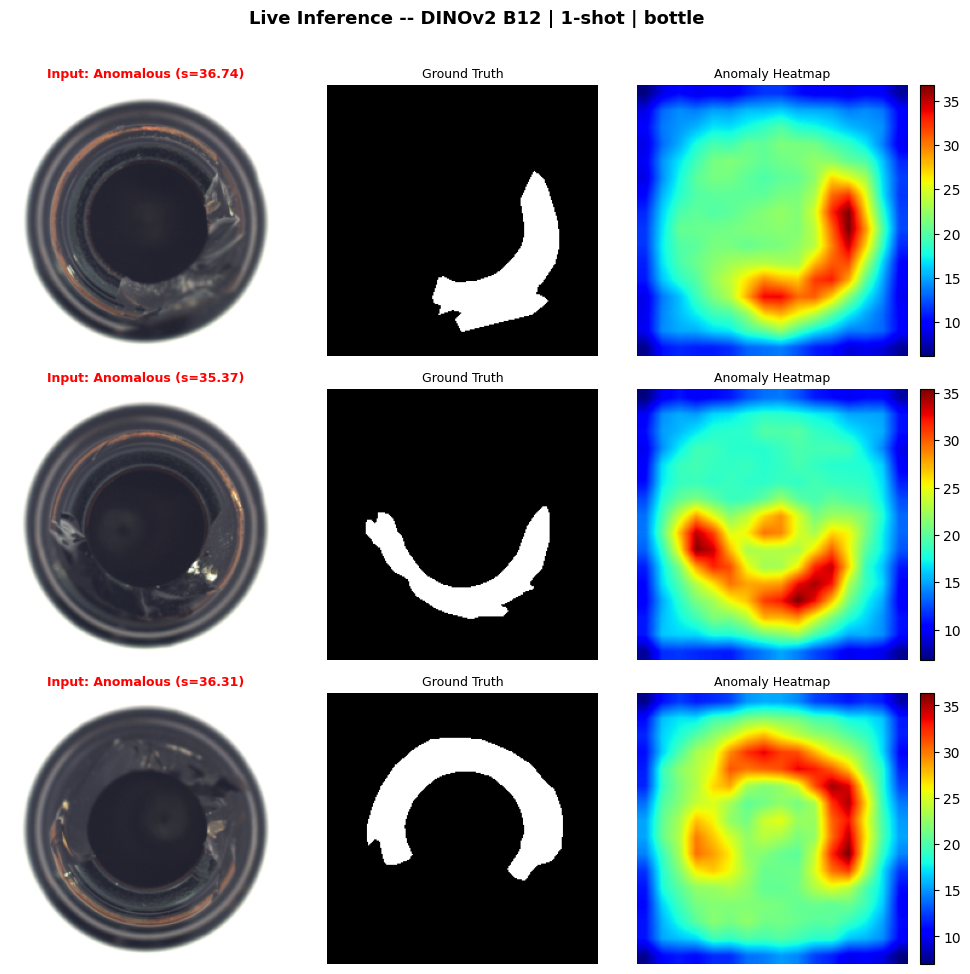


Latency: 22.18 +/- 4.13 ms/image (45 FPS)


3166

In [9]:
# -- CELL 8 : Live inference demo ---------------------------------------------------

# Find best DINOv2 block for 1-shot on bottle
primary_cat = "bottle"
shot_labels = ["1-shot", "5-shot", "10-shot", "Full"]
model_names = ["ResNet-50"] + [f"DINOv2 B{b}" for b in ABLATION_BLOCKS]

# Identify best DINOv2 block per shot count
print("Best DINOv2 block per shot count (bottle):")
for sl in shot_labels:
    dino_models = [(mn, all_results[primary_cat][mn][sl])
                   for mn in model_names if mn.startswith("DINOv2")]
    best_name, best_val = max(dino_models, key=lambda x: x[1])
    resnet_val = all_results[primary_cat]["ResNet-50"][sl]
    delta = best_val - resnet_val
    print(f"  {sl:>8s}: {best_name} = {best_val:.4f} vs ResNet = {resnet_val:.4f} (delta = {delta:+.4f})")

# Use best 1-shot block for the live demo
dino_1shot = [(f"DINOv2 B{b}", all_results[primary_cat][f"DINOv2 B{b}"]["1-shot"])
              for b in ABLATION_BLOCKS]
best_name, best_auroc = max(dino_1shot, key=lambda x: x[1])
best_block = int(best_name.split("B")[1])
print(f"\nDemo model: {best_name} (1-shot AUROC = {best_auroc:.4f})")

# Build model and run inference
train_loader, test_loader = make_loaders(primary_cat, n_shot=1, batch_size=1)
model = PatchCore(backbone_name="dinov2", block_indices=[best_block],
                  device=device, image_size=IMAGE_SIZE, n_shot=1)
model.fit(train_loader, save_checkpoint=False, log=False)

demo_images, demo_labels, demo_masks, demo_maps, demo_scores = [], [], [], [], []
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        scores, maps = model._score_batch(images)
        demo_images.append(batch["image"])
        demo_labels.append(batch["label"])
        demo_masks.append(batch["mask"])
        demo_maps.append(maps.cpu())
        demo_scores.append(scores.cpu())
        if sum(len(x) for x in demo_images) >= 30:
            break

all_imgs = torch.cat(demo_images)
all_lbls = torch.cat(demo_labels)
all_msks = torch.cat(demo_masks)
all_mps  = torch.cat(demo_maps).numpy()
all_scrs = torch.cat(demo_scores).numpy()

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

normal_idx = (all_lbls == 0).nonzero(as_tuple=True)[0][:3].tolist()
anom_idx   = (all_lbls == 1).nonzero(as_tuple=True)[0][:3].tolist()
idx_list   = normal_idx + anom_idx
n_show = len(idx_list)

fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.2 * n_show))
if n_show == 1: axes = axes[np.newaxis, :]

for row, i in enumerate(idx_list):
    img  = denormalize(all_imgs[i])
    mask = all_msks[i, 0].numpy()
    smap = all_mps[i]
    is_anom = all_lbls[i].item() == 1
    color = "red" if is_anom else "green"
    tag = f"Anomalous (s={all_scrs[i]:.2f})" if is_anom else f"Normal (s={all_scrs[i]:.2f})"

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Input: {tag}", color=color, fontweight="bold", fontsize=9)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Ground Truth", fontsize=9)
    axes[row, 1].axis("off")
    im = axes[row, 2].imshow(smap, cmap="jet")
    axes[row, 2].set_title("Anomaly Heatmap", fontsize=9)
    axes[row, 2].axis("off")
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

fig.suptitle(f"Live Inference -- {best_name} | 1-shot | {primary_cat}",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/ckpt3_live_inference.png", dpi=150, bbox_inches="tight")
plt.show()

# Latency
lat_mean, lat_std = model.benchmark_latency(test_loader)
print(f"\nLatency: {lat_mean:.2f} +/- {lat_std:.2f} ms/image ({1000/lat_mean:.0f} FPS)")
del model; torch.cuda.empty_cache(); gc.collect()

## Comparison Results

Full comparison across all categories, models, and shot counts.

In [10]:
# -- CELL 9 : Comparison tables per category ---------------------------------------

shot_labels = ["1-shot", "5-shot", "10-shot", "Full"]
model_names = ["ResNet-50"] + [f"DINOv2 B{b}" for b in ABLATION_BLOCKS]

for cat in CATEGORIES:
    print(f"\n{'='*75}")
    print(f"  {cat.upper()} -- ResNet-50 vs DINOv2 Layer-Wise Ablation")
    print(f"{'='*75}")

    rows = []
    for sl in shot_labels:
        row = {"N-Shot": sl}
        for mn in model_names:
            row[mn] = all_results[cat][mn][sl]
        rows.append(row)

    df = pd.DataFrame(rows)
    print(df.to_string(index=False, float_format="%.4f"))

    # Improvement summary
    print(f"\n  Best DINOv2 vs ResNet-50:")
    for sl in shot_labels:
        resnet_val = all_results[cat]["ResNet-50"][sl]
        dino_vals = [(mn, all_results[cat][mn][sl]) for mn in model_names if mn.startswith("DINOv2")]
        best_name, best_val = max(dino_vals, key=lambda x: x[1])
        delta = best_val - resnet_val
        marker = " <<<" if delta > 0.05 else ""
        print(f"    {sl:>8s}: ResNet={resnet_val:.4f} | {best_name}={best_val:.4f} | "
              f"Delta={delta:+.4f} ({delta*100:+.1f}pp){marker}")

# -- Cross-category average --
print(f"\n{'='*75}")
print(f"  CROSS-CATEGORY AVERAGE (Mean AUROC)")
print(f"{'='*75}")
avg_rows = []
for sl in shot_labels:
    row = {"N-Shot": sl}
    for mn in model_names:
        vals = [all_results[cat][mn][sl] for cat in CATEGORIES]
        row[mn] = np.mean(vals)
    avg_rows.append(row)

df_avg = pd.DataFrame(avg_rows)
print(df_avg.to_string(index=False, float_format="%.4f"))

# Save all results
df_avg.to_csv("/content/ckpt3_avg_results.csv", index=False)
print("\nSaved: /content/ckpt3_avg_results.csv")


  BOTTLE -- ResNet-50 vs DINOv2 Layer-Wise Ablation
 N-Shot  ResNet-50  DINOv2 B3  DINOv2 B6  DINOv2 B9  DINOv2 B12
 1-shot     0.9937     0.9849     0.9921     0.5810      1.0000
 5-shot     0.9984     0.9786     0.9976     0.7238      0.9992
10-shot     0.9984     0.9746     0.9968     0.5984      1.0000
   Full     1.0000     0.9817     0.9992     0.8794      1.0000

  Best DINOv2 vs ResNet-50:
      1-shot: ResNet=0.9937 | DINOv2 B12=1.0000 | Delta=+0.0063 (+0.6pp)
      5-shot: ResNet=0.9984 | DINOv2 B12=0.9992 | Delta=+0.0008 (+0.1pp)
     10-shot: ResNet=0.9984 | DINOv2 B12=1.0000 | Delta=+0.0016 (+0.2pp)
        Full: ResNet=1.0000 | DINOv2 B12=1.0000 | Delta=+0.0000 (+0.0pp)

  CABLE -- ResNet-50 vs DINOv2 Layer-Wise Ablation
 N-Shot  ResNet-50  DINOv2 B3  DINOv2 B6  DINOv2 B9  DINOv2 B12
 1-shot     0.7599     0.7103     0.8596     0.3962      0.8887
 5-shot     0.9325     0.7571     0.8750     0.4325      0.9185
10-shot     0.8272     0.8085     0.8814     0.4655      0.899

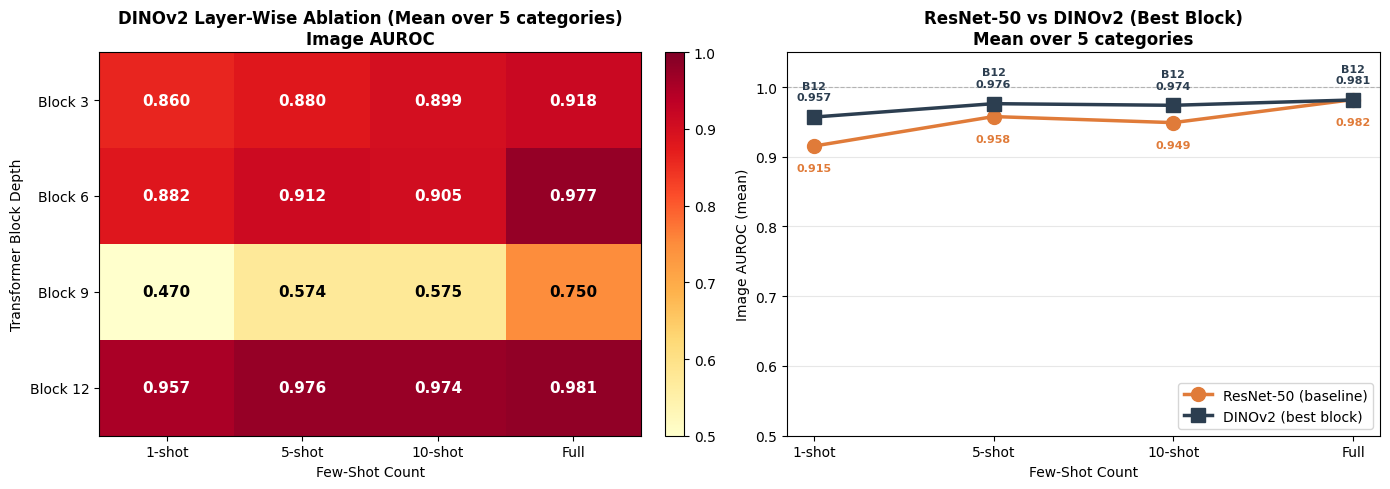

In [11]:
# -- CELL 10 : Ablation heatmap + few-shot efficiency curve ------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use cross-category average for main figures
shot_labels = ["1-shot", "5-shot", "10-shot", "Full"]

# -- (a) Ablation heatmap --
heatmap_data = np.array([
    [np.mean([all_results[cat][f"DINOv2 B{blk}"][sl] for cat in CATEGORIES])
     for sl in shot_labels]
    for blk in ABLATION_BLOCKS
])

im = axes[0].imshow(heatmap_data, cmap="YlOrRd", aspect="auto", vmin=0.5, vmax=1.0)
axes[0].set_xticks(range(len(shot_labels)))
axes[0].set_xticklabels(shot_labels)
axes[0].set_yticks(range(len(ABLATION_BLOCKS)))
axes[0].set_yticklabels([f"Block {b}" for b in ABLATION_BLOCKS])
axes[0].set_title(f"DINOv2 Layer-Wise Ablation (Mean over {len(CATEGORIES)} categories)\n"
                  f"Image AUROC", fontweight="bold")
axes[0].set_xlabel("Few-Shot Count")
axes[0].set_ylabel("Transformer Block Depth")

for i in range(len(ABLATION_BLOCKS)):
    for j in range(len(shot_labels)):
        val = heatmap_data[i, j]
        axes[0].text(j, i, f"{val:.3f}", ha="center", va="center",
                     fontsize=11, fontweight="bold",
                     color="white" if val > 0.85 else "black")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# -- (b) Line plot: ResNet vs best DINOv2 --
x_pos = range(len(shot_labels))
resnet_avg = [np.mean([all_results[cat]["ResNet-50"][sl] for cat in CATEGORIES])
              for sl in shot_labels]
best_dino_avg = []
best_block_labels = []
for sl in shot_labels:
    block_avgs = {}
    for blk in ABLATION_BLOCKS:
        block_avgs[blk] = np.mean([all_results[cat][f"DINOv2 B{blk}"][sl] for cat in CATEGORIES])
    best_blk = max(ABLATION_BLOCKS, key=lambda b: block_avgs[b])
    best_dino_avg.append(block_avgs[best_blk])
    best_block_labels.append(f"B{best_blk}")

axes[1].plot(x_pos, resnet_avg, 'o-', color="#e07b39", linewidth=2.5,
             markersize=10, label="ResNet-50 (baseline)", zorder=3)
axes[1].plot(x_pos, best_dino_avg, 's-', color="#2c3e50", linewidth=2.5,
             markersize=10, label="DINOv2 (best block)", zorder=3)

for i, (val, blk) in enumerate(zip(best_dino_avg, best_block_labels)):
    axes[1].annotate(f"{blk}\n{val:.3f}", (i, val),
                     textcoords="offset points", xytext=(0, 12),
                     ha="center", fontsize=8, fontweight="bold", color="#2c3e50")
for i, val in enumerate(resnet_avg):
    axes[1].annotate(f"{val:.3f}", (i, val),
                     textcoords="offset points", xytext=(0, -18),
                     ha="center", fontsize=8, fontweight="bold", color="#e07b39")

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(shot_labels)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel("Image AUROC (mean)")
axes[1].set_xlabel("Few-Shot Count")
axes[1].set_title(f"ResNet-50 vs DINOv2 (Best Block)\nMean over {len(CATEGORIES)} categories",
                  fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig("/content/ckpt3_ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

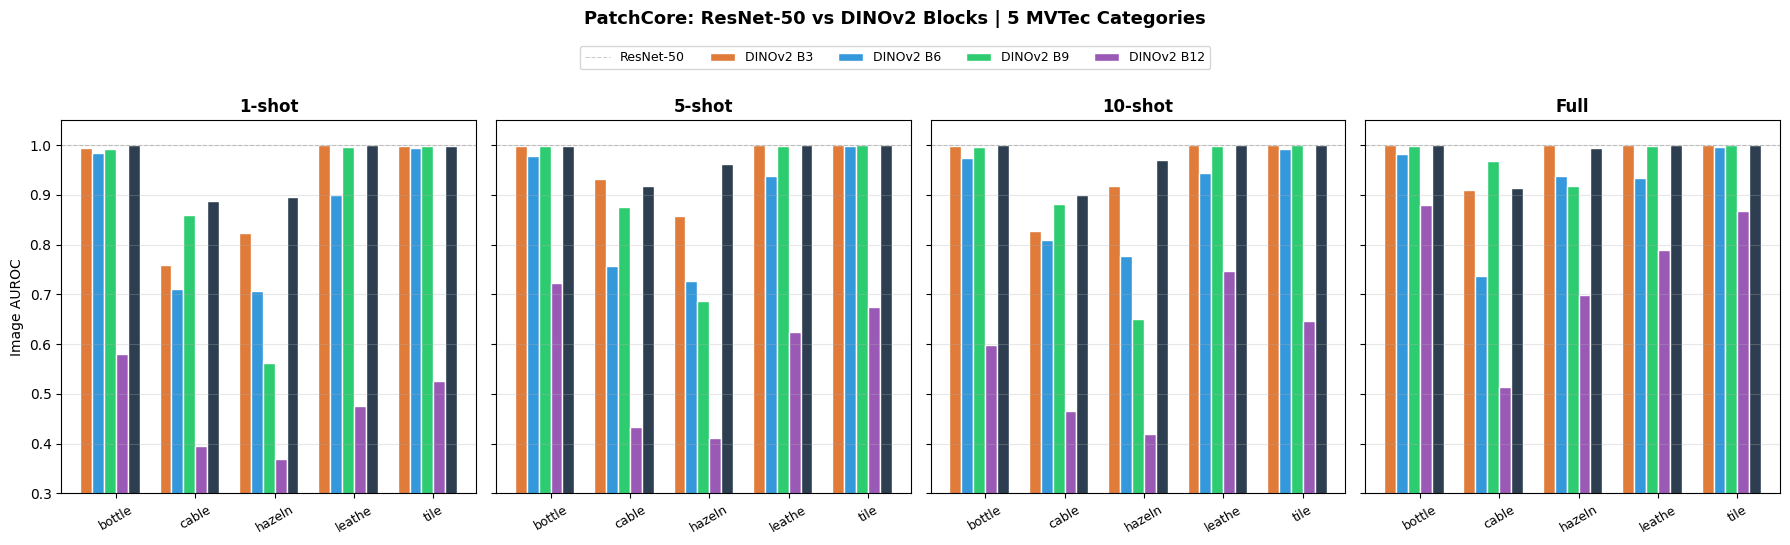


  CHECKPOINT 3 -- FINAL SUMMARY

  Categories tested: ['bottle', 'cable', 'hazelnut', 'leather', 'tile']
  Models: ['ResNet-50', 'DINOv2 B3', 'DINOv2 B6', 'DINOv2 B9', 'DINOv2 B12']
  Shot counts: ['1-shot', '5-shot', '10-shot', 'Full']
  Total experiments: 100

  --- 1-shot ---
    ResNet-50 avg: 0.9153
    DINOv2 B3 avg:  0.8596 (delta=-0.0557)
    DINOv2 B6 avg:  0.8819 (delta=-0.0334)
    DINOv2 B9 avg:  0.4695 (delta=-0.4458)
    DINOv2 B12 avg:  0.9569 (delta=+0.0416)

  --- 5-shot ---
    ResNet-50 avg: 0.9576
    DINOv2 B3 avg:  0.8797 (delta=-0.0779)
    DINOv2 B6 avg:  0.9119 (delta=-0.0457)
    DINOv2 B9 avg:  0.5736 (delta=-0.3841)
    DINOv2 B12 avg:  0.9761 (delta=+0.0185)

  --- 10-shot ---
    ResNet-50 avg: 0.9489
    DINOv2 B3 avg:  0.8991 (delta=-0.0498)
    DINOv2 B6 avg:  0.9052 (delta=-0.0437)
    DINOv2 B9 avg:  0.5755 (delta=-0.3735)
    DINOv2 B12 avg:  0.9738 (delta=+0.0249)

  --- Full ---
    ResNet-50 avg: 0.9819
    DINOv2 B3 avg:  0.9178 (delta=-0.0641)


In [12]:
# -- CELL 11 : Per-category grouped bar chart + final summary ----------------------

n_cats = len(CATEGORIES)
shot_labels = ["1-shot", "5-shot", "10-shot", "Full"]
model_names = ["ResNet-50"] + [f"DINOv2 B{b}" for b in ABLATION_BLOCKS]
model_colors = {"ResNet-50": "#e07b39",
                "DINOv2 B3": "#3498db", "DINOv2 B6": "#2ecc71",
                "DINOv2 B9": "#9b59b6", "DINOv2 B12": "#2c3e50"}

# One subplot per shot count
fig, axes = plt.subplots(1, len(shot_labels), figsize=(4.5 * len(shot_labels), 5), sharey=True)
bar_width = 0.15
x = np.arange(n_cats)

for ax_idx, sl in enumerate(shot_labels):
    ax = axes[ax_idx]
    for m_idx, mn in enumerate(model_names):
        vals = [all_results[cat][mn][sl] for cat in CATEGORIES]
        offset = (m_idx - len(model_names)/2) * bar_width
        ax.bar(x + offset, vals, bar_width, label=mn if ax_idx == 0 else "",
               color=model_colors.get(mn, "gray"), edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels([c[:6] for c in CATEGORIES], fontsize=9, rotation=30)
    ax.set_title(sl, fontweight="bold")
    ax.set_ylim(0.3, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.4)

axes[0].set_ylabel("Image AUROC")
fig.legend(model_names, loc="upper center", ncol=len(model_names),
           bbox_to_anchor=(0.5, 1.02), fontsize=9)
fig.suptitle(f"PatchCore: ResNet-50 vs DINOv2 Blocks | {len(CATEGORIES)} MVTec Categories",
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()
plt.savefig("/content/ckpt3_category_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# ========== FINAL SUMMARY ==========
print("\n" + "=" * 65)
print("  CHECKPOINT 3 -- FINAL SUMMARY")
print("=" * 65)

# Overall best block
print(f"\n  Categories tested: {CATEGORIES}")
print(f"  Models: {model_names}")
print(f"  Shot counts: {shot_labels}")
print(f"  Total experiments: {len(CATEGORIES) * len(model_names) * len(shot_labels)}")

for sl in shot_labels:
    print(f"\n  --- {sl} ---")
    resnet_avg = np.mean([all_results[cat]["ResNet-50"][sl] for cat in CATEGORIES])
    print(f"    ResNet-50 avg: {resnet_avg:.4f}")
    for blk in ABLATION_BLOCKS:
        mn = f"DINOv2 B{blk}"
        avg = np.mean([all_results[cat][mn][sl] for cat in CATEGORIES])
        delta = avg - resnet_avg
        print(f"    {mn} avg:  {avg:.4f} (delta={delta:+.4f})")

print(f"\n  Checkpoints: {len(list(CKPT_DIR.iterdir()))} files")
print(f"  Log entries: ", end="")
with open(LOG_DIR / "training_log.jsonl") as f:
    print(f"{sum(1 for _ in f)}")

print("\n  Scope note for final report:")
print("    - Supervised ViT-B/16 and KNN pixel baselines deferred (future work)")
print("    - PCA compression and pixel-level PRO-score deferred (future work)")
print("    - These are noted as planned extensions, not missing deliverables")
print("=" * 65)

In [13]:
# -- CELL 12 : Full training log display -------------------------------------------

print("Training Log -- Memory Bank Construction Records")
print("=" * 80)
with open(LOG_DIR / "training_log.jsonl") as f:
    for i, line in enumerate(f, 1):
        entry = json.loads(line)
        print(f"\n[{i:02d}] {entry['timestamp']}")
        print(f"     Backbone:  {entry['backbone']}")
        print(f"     Blocks:    {entry.get('block_indices', 'layer2+layer3')}")
        print(f"     Images:    {entry['n_train_images']}")
        print(f"     Coreset:   {entry['coreset_ratio']:.0%} -> {entry['raw_patches']} -> {entry['coreset_patches']} patches")
        print(f"     Feat dim:  {entry['feat_dim']}")
        print(f"     Build:     {entry['build_time_sec']}s | {entry['memory_bank_MB']} MB")
        if 'checkpoint_file' in entry:
            print(f"     Saved:     {entry['checkpoint_file']}")

Training Log -- Memory Bank Construction Records

[01] 2026-03-31T03:56:20.839901
     Backbone:  resnet50
     Blocks:    None
     Images:    1
     Coreset:   100% -> 784 -> 784 patches
     Feat dim:  1536
     Build:     1.03s | 4.82 MB
     Saved:     membank_resnet50_blkl2l3_1shot.pt

[02] 2026-03-31T03:56:24.935710
     Backbone:  resnet50
     Blocks:    None
     Images:    5
     Coreset:   25% -> 3920 -> 980 patches
     Feat dim:  1536
     Build:     0.49s | 6.02 MB
     Saved:     membank_resnet50_blkl2l3_5shot.pt

[03] 2026-03-31T03:56:28.810273
     Backbone:  resnet50
     Blocks:    None
     Images:    10
     Coreset:   10% -> 7840 -> 784 patches
     Feat dim:  1536
     Build:     0.55s | 4.82 MB
     Saved:     membank_resnet50_blkl2l3_10shot.pt

[04] 2026-03-31T03:56:39.113929
     Backbone:  resnet50
     Blocks:    None
     Images:    209
     Coreset:   1% -> 163856 -> 1638 patches
     Feat dim:  1536
     Build:     7.35s | 10.06 MB
     Saved:     memban